Análise dos Microdados do ENEM – Goiás

Disciplina: CESAR  
Curso:Ciência de Dados / IA  
Instituição: UNISO  

Este notebook apresenta uma análise exploratória dos microdados do ENEM,
com foco nos participantes do estado de Goiás.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [9]:
import pandas as pd

df_resultados = pd.read_csv(
    "../dados/bruto/RESULTADOS_2024.csv",
    sep=";",
    encoding="latin1",
    low_memory=False
)

df_participantes = pd.read_csv(
    "../dados/bruto/PARTICIPANTES_2024.csv",
    sep=";",
    encoding="latin1",
    low_memory=False
)

df_resultados.shape, df_participantes.shape


((4332944, 42), (4332944, 38))

In [10]:
df_resultados.head()
df_participantes.info()


<class 'pandas.DataFrame'>
RangeIndex: 4332944 entries, 0 to 4332943
Data columns (total 38 columns):
 #   Column              Dtype  
---  ------              -----  
 0   NU_INSCRICAO        int64  
 1   NU_ANO              int64  
 2   TP_FAIXA_ETARIA     int64  
 3   TP_SEXO             str    
 4   TP_ESTADO_CIVIL     int64  
 5   TP_COR_RACA         int64  
 6   TP_NACIONALIDADE    int64  
 7   TP_ST_CONCLUSAO     int64  
 8   TP_ANO_CONCLUIU     int64  
 9   TP_ENSINO           float64
 10  IN_TREINEIRO        int64  
 11  CO_MUNICIPIO_PROVA  int64  
 12  NO_MUNICIPIO_PROVA  str    
 13  CO_UF_PROVA         int64  
 14  SG_UF_PROVA         str    
 15  Q001                str    
 16  Q002                str    
 17  Q003                str    
 18  Q004                str    
 19  Q005                int64  
 20  Q006                str    
 21  Q007                str    
 22  Q008                str    
 23  Q009                str    
 24  Q010                str    
 25  Q0

In [11]:
df_go_resultados = df_resultados[df_resultados["SG_UF_PROVA"] == "GO"]
df_go_participantes = df_participantes[df_participantes["SG_UF_PROVA"] == "GO"]


## Pergunta 1 — Distribuição por sexo dos inscritos em GO

TP_SEXO
F    90638
M    60520
Name: count, dtype: int64


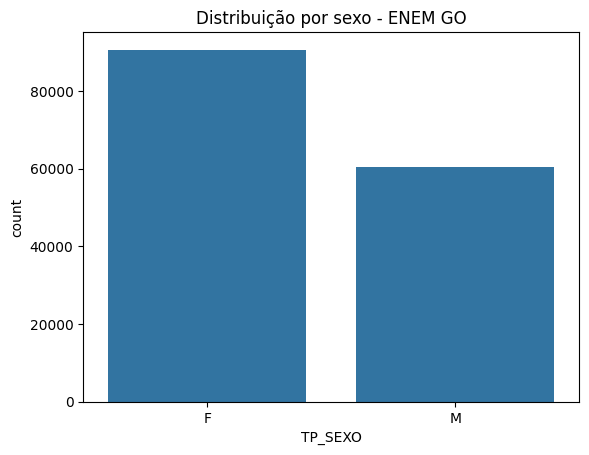

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sexo_counts = df_go_participantes["TP_SEXO"].value_counts()

print(sexo_counts)

sns.countplot(data=df_go_participantes, x="TP_SEXO")
plt.title("Distribuição por sexo - ENEM GO")
plt.show()


Interpretação: Mostra quantos homens e mulheres participaram.

## Pergunta 2 — Faixa etária mais comum

TP_FAIXA_ETARIA
3     41003
2     37403
1     22901
4     13358
5      6924
11     5746
6      4673
7      3341
12     3227
8      2604
13     2394
9      2041
14     1715
10     1681
15     1049
16      583
17      322
18      117
19       48
20       28
Name: count, dtype: int64


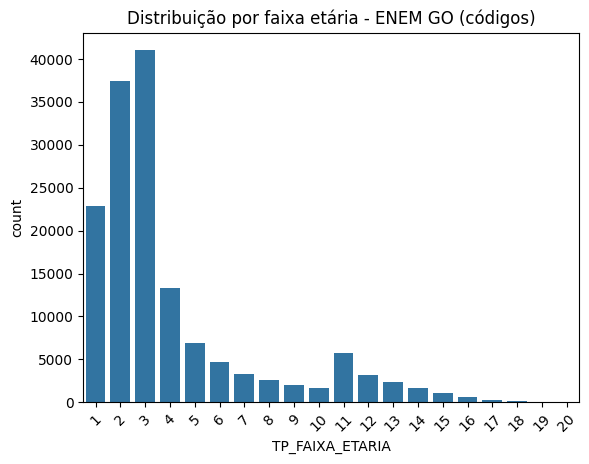

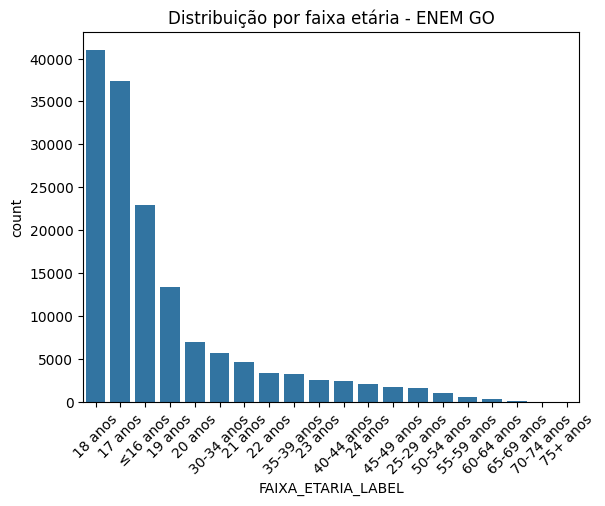

In [20]:
# Original (20 categorias)
faixa_counts = df_go_participantes["TP_FAIXA_ETARIA"].value_counts()
print(faixa_counts)

sns.countplot(data=df_go_participantes, x="TP_FAIXA_ETARIA")
plt.title("Distribuição por faixa etária - ENEM GO (códigos)")
plt.xticks(rotation=45)
plt.show()

faixa_map = {
    1: "≤16 anos",
    2: "17 anos",
    3: "18 anos",
    4: "19 anos",
    5: "20 anos",
    6: "21 anos",
    7: "22 anos",
    8: "23 anos",
    9: "24 anos",
    10: "25-29 anos",
    11: "30-34 anos",
    12: "35-39 anos",
    13: "40-44 anos",
    14: "45-49 anos",
    15: "50-54 anos",
    16: "55-59 anos",
    17: "60-64 anos",
    18: "65-69 anos",
    19: "70-74 anos",
    20: "75+ anos"
}

df_go_participantes["FAIXA_ETARIA_LABEL"] = df_go_participantes["TP_FAIXA_ETARIA"].map(faixa_map)

sns.countplot(data=df_go_participantes, x="FAIXA_ETARIA_LABEL",
              order=df_go_participantes["FAIXA_ETARIA_LABEL"].value_counts().index)
plt.title("Distribuição por faixa etária - ENEM GO")
plt.xticks(rotation=45)
plt.show()


Interpretação: Identifique qual faixa etária concentra mais participantes

## Pergunta 3 — Distribuição por cor/raça declarada

TP_COR_RACA
3    69419
1    58557
2    17000
4     3294
0     2253
5      635
Name: count, dtype: int64


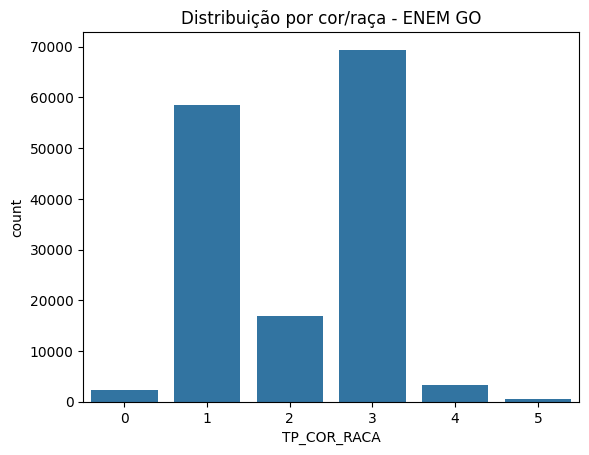

In [14]:
raca_counts = df_go_participantes["TP_COR_RACA"].value_counts()
print(raca_counts)

sns.countplot(data=df_go_participantes, x="TP_COR_RACA")
plt.title("Distribuição por cor/raça - ENEM GO")
plt.show()


Interpretação: Mostra a diversidade racial dos inscritos em Goiás.

## Pergunta 4 — Proporção de treineiros

IN_TREINEIRO
0    77.147753
1    22.852247
Name: proportion, dtype: float64


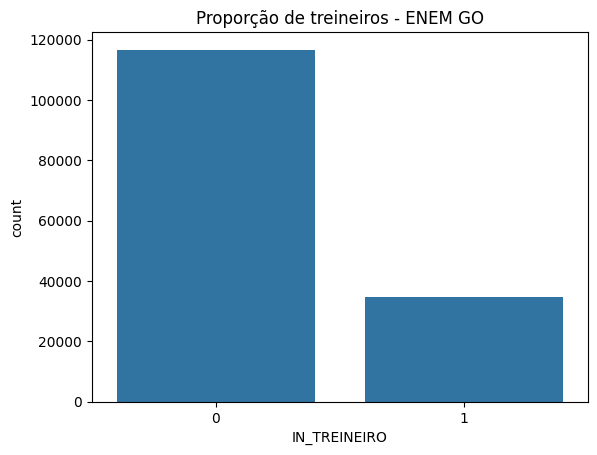

In [15]:
treineiro_counts = df_go_participantes["IN_TREINEIRO"].value_counts(normalize=True) * 100
print(treineiro_counts)

sns.countplot(data=df_go_participantes, x="IN_TREINEIRO")
plt.title("Proporção de treineiros - ENEM GO")
plt.show()


Interpretação: Indica quantos participantes fizeram a prova apenas como treino (sem valer para ingresso).